## DS6015-006 
## Derrick Clarke (thq3hn)

### Generating Capstone Visualizations

### Install Required Libraries

In [24]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm

import pyproj

import numpy as np

import datashader as ds
import datashader.transfer_functions as tf

import rasterio

### Tree Crown Centroid Density Map

In [20]:
FEET_TO_METERS = 0.3048006096   # US Survey Foot exact conversion

# Load the master centroid CSV produced by Tree Canopy Data pipeline 
dfTreeCrownCDMap: pd.DataFrame = pd.read_csv("../../data/outputs/all_tiles_centroids-albemarle.csv")

# Convert US Survey Feet → metres
dfTreeCrownCDMap["easting_m_utm"]  = dfTreeCrownCDMap["easting_m"]  * FEET_TO_METERS
dfTreeCrownCDMap["northing_m_utm"] = dfTreeCrownCDMap["northing_m"] * FEET_TO_METERS

# Preview
print(f"Total crowns loaded: {len(dfTreeCrownCDMap):,}")

print("UTM easting  range:", dfTreeCrownCDMap["easting_m_utm"].min(),  "–", dfTreeCrownCDMap["easting_m_utm"].max())
print("UTM northing range:", dfTreeCrownCDMap["northing_m_utm"].min(), "–", dfTreeCrownCDMap["northing_m_utm"].max())

print(dfTreeCrownCDMap.head())

Total crowns loaded: 14,686,134
UTM easting  range: 62517.500634751195 – 3488442.8244716953
UTM northing range: 1153670.4566882988 – 1289916.0271220945
                                             tile_id   easting_m  northing_m  \
0  USGS_LPC_VA_ChesapeakeBay_2015_LAS_S13_3889_30...  11386052.5   3899180.5   
1  USGS_LPC_VA_ChesapeakeBay_2015_LAS_S13_3889_30...  11387768.5   3899178.5   
2  USGS_LPC_VA_ChesapeakeBay_2015_LAS_S13_3889_30...  11387761.5   3899175.5   
3  USGS_LPC_VA_ChesapeakeBay_2015_LAS_S13_3889_30...  11386057.5   3899173.5   
4  USGS_LPC_VA_ChesapeakeBay_2015_LAS_S13_3889_30...  11387767.5   3899173.5   

   height_m  easting_m_utm  northing_m_utm  
0     59.90   3.470476e+06    1.188473e+06  
1     59.91   3.470999e+06    1.188472e+06  
2     59.90   3.470997e+06    1.188471e+06  
3     58.97   3.470477e+06    1.188470e+06  
4     59.55   3.470998e+06    1.188470e+06  


In [21]:
# Reproject: EPSG:2284 (VA State Plane South, US Survey Feet)
#          → EPSG:32618 (UTM Zone 18N, metres)
# transformer = pyproj.Transformer.from_crs("EPSG:2284", "EPSG:32618", always_xy=True)
# dfTreeCrownCDMap['utm_easting'], dfTreeCrownCDMap['utm_northing'] = transformer.transform(
#     dfTreeCrownCDMap['easting_m'].values,
#     dfTreeCrownCDMap['northing_m'].values
# )

# print("UTM easting  range:", round(dfTreeCrownCDMap['utm_easting'].min()), "–", round(dfTreeCrownCDMap['utm_easting'].max()))
# print("UTM northing range:", round(dfTreeCrownCDMap['utm_northing'].min()), "–", round(dfTreeCrownCDMap['utm_northing'].max()))


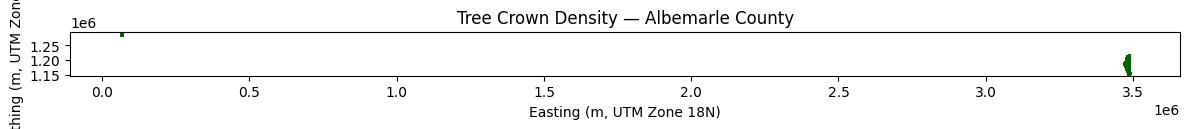

In [22]:

# Convert to GeoDataFrame (UTM Zone 18N)
# gdf = gpd.GeoDataFrame(
#     dfTreeCrownCDMap,
#     geometry=gpd.points_from_xy(dfTreeCrownCDMap.easting_m, dfTreeCrownCDMap.northing_m),
#     crs="EPSG:32618"
# )

gdf = gpd.GeoDataFrame(
    dfTreeCrownCDMap,
    geometry=gpd.points_from_xy(dfTreeCrownCDMap.easting_m_utm, dfTreeCrownCDMap.northing_m_utm),
    crs="EPSG:32618"
)

# creates a new blank plotting canvas
fig, ax = plt.subplots(figsize=(12, 10))

# Generate crown density map 
#gdf.plot(ax=ax, markersize=0.1, alpha=0.3, color='darkgreen')
gdf.plot(ax=ax, markersize=0.05, alpha=0.2, color="darkgreen")
ax.set_title("Tree Crown Density — Albemarle County")

ax.set_xlabel("Easting (m, UTM Zone 18N)")
ax.set_ylabel("Northing (m, UTM Zone 18N)")
plt.tight_layout()

plt.show()
#plt.savefig("crown_density_map.png", dpi=300)


## Plotting 4.4 million individual points with gdf.plot() will work but the resulting PNG will be visually saturated — most points will overlap and obscure each other.

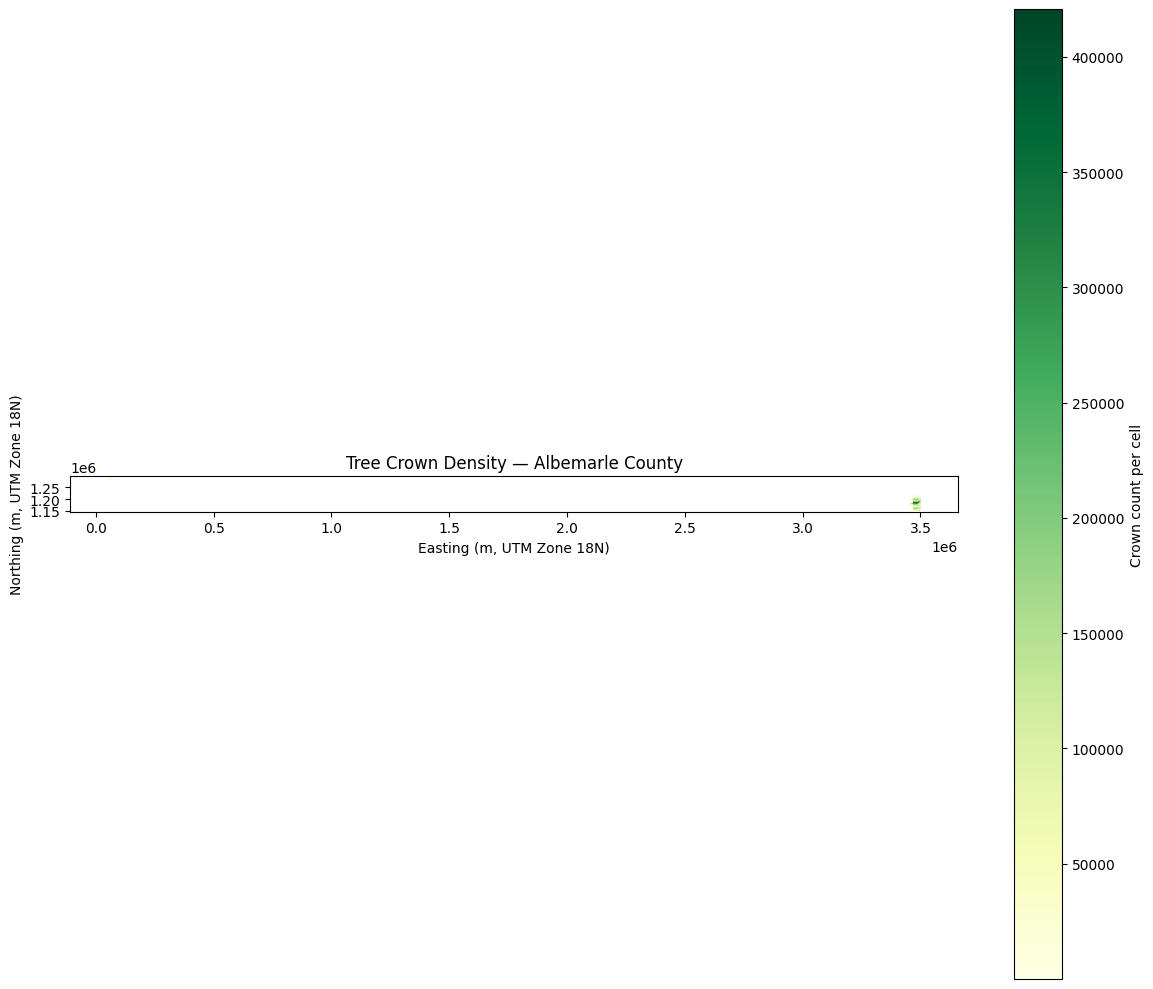

In [23]:
# creates a new blank plotting canvas
fig, ax = plt.subplots(figsize=(12, 10))

# hb = ax.hexbin(dfTreeCrownCDMap.easting_m, dfTreeCrownCDMap.northing_m,
#                gridsize=200, cmap='YlGn', mincnt=1)

# hb = ax.hexbin(dfTreeCrownCDMap.utm_easting, dfTreeCrownCDMap.utm_northing,
#                 gridsize=200, cmap='YlGn', mincnt=1)

hb = ax.hexbin(
    dfTreeCrownCDMap.easting_m_utm,
    dfTreeCrownCDMap.northing_m_utm,
    gridsize=200,
    cmap="YlGn",
    mincnt=1
)

plt.colorbar(hb, ax=ax, label="Crown count per cell")

ax.set_title("Tree Crown Density — Albemarle County")

ax.set_xlabel('Easting (m, UTM Zone 18N)')
ax.set_ylabel('Northing (m, UTM Zone 18N)')

ax.set_aspect("equal")

plt.tight_layout()

plt.show()
#plt.savefig("../../data/outputs/crown_density_hexbin.png", dpi=300)

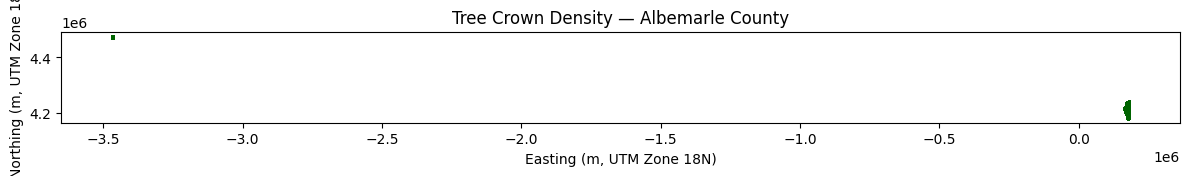

In [17]:
fig, ax = plt.subplots(figsize=(12, 10))
ax.scatter(dfTreeCrownCDMap.utm_easting, dfTreeCrownCDMap.utm_northing, s=0.05, alpha=0.3, color='darkgreen')
ax.set_title('Tree Crown Density — Albemarle County')
ax.set_xlabel('Easting (m, UTM Zone 18N)')
ax.set_ylabel('Northing (m, UTM Zone 18N)')
ax.set_aspect('equal')
plt.tight_layout()
#plt.savefig('crown_density_map.png', dpi=300)
plt.show()

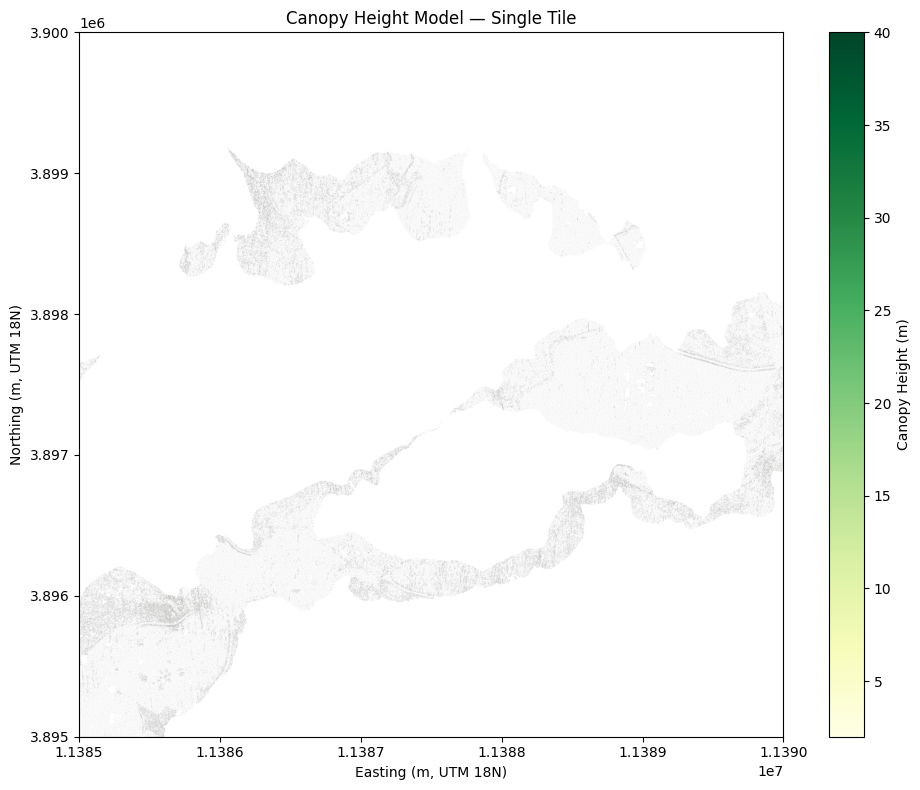

In [26]:
# Load one CHM tile
chm_path = "../../data/outputs/GeoTIFF_files/albemarle_county/" \
           "USGS_LPC_VA_ChesapeakeBay_2015_LAS_S13_3889_30_chm.tif"

with rasterio.open(chm_path) as src:
    chm  = src.read(1).astype(np.float32)
    meta = src.meta
    extent = [src.bounds.left, src.bounds.right,
              src.bounds.bottom, src.bounds.top]

# Replace no-data with NaN
chm = np.where(chm == meta["nodata"], np.nan, chm)

# Plot
fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(chm, cmap="YlGn", vmin=2, vmax=40, extent=extent)
plt.colorbar(im, ax=ax, label="Canopy Height (m)")
ax.set_title("Canopy Height Model — Single Tile")
ax.set_xlabel("Easting (m, UTM 18N)")
ax.set_ylabel("Northing (m, UTM 18N)")
plt.tight_layout()
plt.show()
#plt.savefig("chm_single_tile.png", dpi=300)